--- Classification Report ---
              precision    recall  f1-score   support

           0       0.59      0.50      0.54        54
           1       0.50      0.59      0.54        46

    accuracy                           0.54       100
   macro avg       0.54      0.54      0.54       100
weighted avg       0.55      0.54      0.54       100



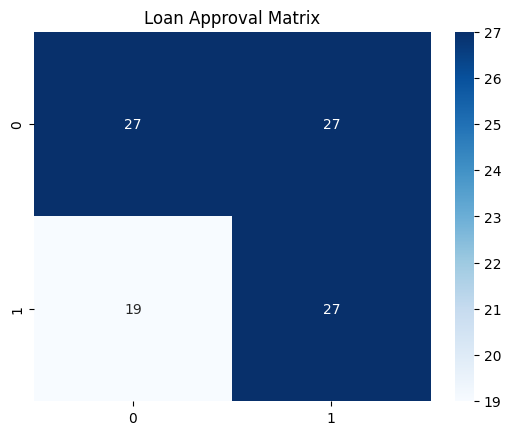

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Sample Dataset Generate karna (Kaggle ki zaroorat hi nahi)
np.random.seed(42)
n_samples = 500

data = {
    'loan_id': range(1, n_samples + 1),
    'no_of_dependents': np.random.randint(0, 5, n_samples),
    'education': np.random.choice([' Graduated', ' Not Graduated'], n_samples),
    'self_employed': np.random.choice([' Yes', ' No'], n_samples),
    'income_annum': np.random.randint(200000, 9900000, n_samples),
    'loan_amount': np.random.randint(100000, 30000000, n_samples),
    'loan_term': np.random.choice([2, 4, 6, 8, 10, 12, 14, 16, 18, 20], n_samples),
    'cibil_score': np.random.randint(300, 900, n_samples),
    'loan_status': np.random.choice([' Approved', ' Rejected'], n_samples)
}

df = pd.DataFrame(data)
df.columns = df.columns.str.strip()

# 2. Encoding Text Columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 3. Features & Target Split
X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Training & Evaluation[cite: 1]
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 5. Output Results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Loan Approval Matrix')
plt.show()